In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:


df = pd.read_csv(
    "C:/Users/iyedh/OneDrive/Desktop/figl2/emai_spam_filtering/data/raw/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

print(df.head())
print()
print("Shape :", df.shape)
print()
print("Colonnes :", df.columns.tolist())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Shape : (5572, 2)

Colonnes : ['label', 'message']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [5]:
df.isnull().sum()


label      0
message    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(403)

In [7]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

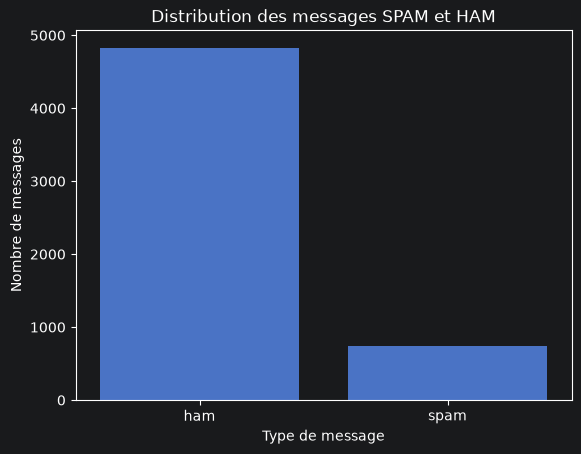

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="label")

plt.title("Distribution des messages SPAM et HAM")
plt.xlabel("Type de message")
plt.ylabel("Nombre de messages")

plt.show()

In [9]:
df["message_length"] = df["message"].str.len()

In [10]:
print(df)

     label                                            message  message_length
0      ham  Go until jurong point, crazy.. Available only ...             111
1      ham                      Ok lar... Joking wif u oni...              29
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...             155
3      ham  U dun say so early hor... U c already then say...              49
4      ham  Nah I don't think he goes to usf, he lives aro...              61
...    ...                                                ...             ...
5567  spam  This is the 2nd time we have tried 2 contact u...             160
5568   ham               Will ü b going to esplanade fr home?              36
5569   ham  Pity, * was in mood for that. So...any other s...              57
5570   ham  The guy did some bitching but I acted like i'd...             125
5571   ham                         Rofl. Its true to its name              26

[5572 rows x 3 columns]


In [11]:
df.groupby("label")["message_length"].mean()

label
ham      71.482487
spam    138.670683
Name: message_length, dtype: float64

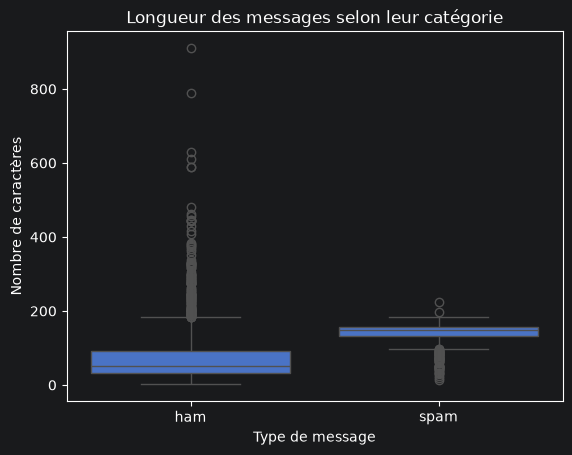

In [12]:
sns.boxplot(data=df, x="label", y="message_length")

plt.title("Longueur des messages selon leur catégorie")
plt.xlabel("Type de message")
plt.ylabel("Nombre de caractères")

plt.show()

In [13]:
df.isnull().sum()

label             0
message           0
message_length    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(403)

In [15]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [16]:
df.groupby("label")["message_length"].mean()

label
ham      71.482487
spam    138.670683
Name: message_length, dtype: float64

In [17]:
df_clean = df.copy()

In [18]:
df_clean = df_clean.drop_duplicates()

In [19]:
print("Nombre de lignes avant :", len(df))
print("Nombre de lignes après :", len(df_clean))
print("Doublons restants :", df_clean.duplicated().sum())

Nombre de lignes avant : 5572
Nombre de lignes après : 5169
Doublons restants : 0


In [20]:
df_clean["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [21]:
df_clean["label"].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

In [22]:
df_clean.to_csv(
    "C:/Users/iyedh/OneDrive/Desktop/figl2/emai_spam_filtering/data/processed/sms_spam_clean.csv",
    index=False
)
import os

path = "C:/Users/iyedh/OneDrive/Desktop/figl2/emai_spam_filtering/data/processed/sms_spam_clean.csv"

print(os.path.exists(path))

True


In [23]:
from src.preprocessing import clean_text

In [24]:
test_message = "Congratulations!!! You WON £1000. Visit www.example.com"

print("Avant :")
print(test_message)

print("\nAprès :")
print(clean_text(test_message))

Avant :
Congratulations!!! You WON £1000. Visit www.example.com

Après :
congratulations you won visit


In [25]:
df_clean["clean_message"] = df_clean["message"].apply(clean_text)

In [26]:
df_clean[["label", "message", "clean_message"]].head(10)

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now a...
6,ham,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,ham,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,spam,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,spam,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...


In [27]:
empty_messages = df_clean["clean_message"].str.strip().eq("").sum()

print("Messages vides :", empty_messages)

Messages vides : 3


In [28]:
empty_rows = df_clean[df_clean["clean_message"].str.strip().eq("")]

print(empty_rows[["label", "message", "clean_message"]])

     label  message clean_message
1612   ham      645              
3376   ham      :)               
4824   ham  :-) :-)              


In [29]:
print(empty_rows["label"].value_counts())

label
ham    3
Name: count, dtype: int64


In [30]:
df_clean = df_clean[df_clean["clean_message"].str.strip() != ""].copy()

In [31]:
print("Nombre de lignes :", len(df_clean))
print("Messages vides :", df_clean["clean_message"].str.strip().eq("").sum())

Nombre de lignes : 5166
Messages vides : 0


In [32]:
X = df_clean["clean_message"]
y = df_clean["label"]
print(X.head())
print()
print(y.head())

0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in a wkly comp to win fa cup final ...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: clean_message, dtype: str

0     ham
1     ham
2    spam
3     ham
4     ham
Name: label, dtype: str


In [33]:
print(y.head(10))
print()
print(y.unique())


0     ham
1     ham
2    spam
3     ham
4     ham
5    spam
6     ham
7     ham
8    spam
9    spam
Name: label, dtype: str

<StringArray>
['ham', 'spam']
Length: 2, dtype: str


In [34]:
print(df_clean["label"].unique())
print(df_clean["label"].astype(str).str.strip().unique())

<StringArray>
['ham', 'spam']
Length: 2, dtype: str
<StringArray>
['ham', 'spam']
Length: 2, dtype: str


In [35]:
# ============================================
# Préparation des données pour le Machine Learning
# ============================================

from sklearn.model_selection import train_test_split

# 1. X = messages nettoyés
X = df_clean["clean_message"]

# 2. y = labels originaux
# On repart de df_clean["label"] pour éviter les NaN
y = df_clean["label"].astype(str).str.strip().str.lower()

# 3. Transformer les labels :
# ham  -> 0
# spam -> 1
y = y.map({"ham": 0, "spam": 1})

# 4. Vérification
print("Labels :", y.unique())
print("Valeurs manquantes :", y.isnull().sum())
print()

# 5. Séparation Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Vérification des dimensions
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print(y)

Labels : [0 1]
Valeurs manquantes : 0

X_train : (4132,)
X_test  : (1034,)
y_train : (4132,)
y_test  : (1034,)
0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: label, Length: 5166, dtype: int64


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("X_train original :", X_train.shape)
print("X_train TF-IDF   :", X_train_tfidf.shape)

print("X_test original :", X_test.shape)
print("X_test TF-IDF   :", X_test_tfidf.shape)

X_train original : (4132,)
X_train TF-IDF   : (4132, 7517)
X_test original : (1034,)
X_test TF-IDF   : (1034, 7517)


In [44]:
from src.model import NaiveBayesSpamClassifier

model = NaiveBayesSpamClassifier()

model.fit(X_train, y_train)

In [53]:
print("Classes :", model.classes)
print("Nombre de mots :", len(model.vocabulary))
print("Nombre HAM :", model.class_counts[0])
print("Nombre SPAM :", model.class_counts[1])

Classes : {0, 1}
Nombre de mots : 7543
Nombre HAM : 3610
Nombre SPAM : 522


In [55]:
from importlib import reload
import src.model

reload(src.model)

<module 'src.model' from 'C:\\Users\\iyedh\\OneDrive\\Desktop\\figl2\\emai_spam_filtering\\src\\model.py'>

In [56]:
from src.model import NaiveBayesSpamClassifier
model = NaiveBayesSpamClassifier()
model.fit(X_train, y_train)
print("free | HAM :", model.word_probability("free", 0))
print("free | SPAM:", model.word_probability("free", 1))
print("money | HAM :", model.word_probability("money", 0))
print("money | SPAM:", model.word_probability("money", 1))

free | HAM : 0.0007501744591765527
free | SPAM: 0.008437449294174915
money | HAM : 0.0006454989532449407
money | SPAM: 0.00027043106712099085


In [68]:
from importlib import reload
import src.model

reload(src.model)

<module 'src.model' from 'C:\\Users\\iyedh\\OneDrive\\Desktop\\figl2\\emai_spam_filtering\\src\\model.py'>

In [73]:
from src.model import NaiveBayesSpamClassifier

In [74]:
model = NaiveBayesSpamClassifier()

In [75]:
model.fit(X_train, y_train)

In [76]:
print(hasattr(model, "predict_one"))

True


In [82]:
prediction = model.predict_one("free monjey now")

print("Prediction :", prediction)

Prediction : 1


In [84]:
from importlib import reload
import src.model

reload(src.model)

from src.model import NaiveBayesSpamClassifier

model = NaiveBayesSpamClassifier()

model.fit(X_train, y_train)

print(hasattr(model, "predict_one"))

prediction = model.predict_one("free money now")

print("Prediction :", prediction)

True
Prediction : 1


In [85]:
messages = [
    "Hey, how are you?",
    "free money now",
    "Congratulations you won a prize",
    "Can we meet tonight?",
    "Call me when you arrive"
]

for message in messages:

    prediction = model.predict_one(message)

    label = "SPAM" if prediction == 1 else "HAM"

    print(message)
    print("Prediction :", label)
    print()

Hey, how are you?
Prediction : HAM

free money now
Prediction : SPAM

Congratulations you won a prize
Prediction : SPAM

Can we meet tonight?
Prediction : HAM

Call me when you arrive
Prediction : HAM



In [86]:
from importlib import reload
import src.model

reload(src.model)

from src.model import NaiveBayesSpamClassifier

In [87]:
model = NaiveBayesSpamClassifier()
model.fit(X_train, y_train)

In [88]:
model = NaiveBayesSpamClassifier()
model.fit(X_train, y_train)

In [89]:
y_pred = model.predict(X_test)

print("Nombre de prédictions :", len(y_pred))
print("Premières prédictions :", y_pred[:20])

Nombre de prédictions : 1034
Premières prédictions : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [91]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.971953578336557
